Convert the Dataframe to CSV file as raw data

In [1]:
import pandas as pd
import re
import html

comments_df = pd.read_csv("raw_data.csv")

Inspect dataset

In [2]:
comments_df.head()

,author,updated_at,like_count,text,video_id,public
0,@kingsman1713,2020-03-30T00:09:44Z,41736,The guy who stay in the ship for 20 years.\n\n...,j3DuONZb3Ik,True
1,@IkanGelamaKuning,2021-08-18T15:33:15Z,37032,A husband waiting for his wife shopping feels ...,JqKa6qyVYgg,True
2,@stevedevries2891,2021-01-05T01:33:47Z,17975,My wife keeps asking me to dust my office. I'...,j3DuONZb3Ik,True
3,@joshfromdundermifflin8973,2020-03-05T18:54:19Z,15427,The scene where cooper comes back to the ship ...,j3DuONZb3Ik,True
4,@Dcook85,2014-11-24T01:48:48Z,15359,I was disappointed to see that Christopher Nol...,R1cexcjdyIE,True


In [3]:
comments_df.isnull().sum()

author        0
updated_at    0
like_count    0
text          7
video_id      0
public        0
dtype: int64

In [4]:
comments_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54427 entries, 0 to 54426
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   author      54427 non-null  str  
 1   updated_at  54427 non-null  str  
 2   like_count  54427 non-null  int64
 3   text        54420 non-null  str  
 4   video_id    54427 non-null  str  
 5   public      54427 non-null  bool 
dtypes: bool(1), int64(1), str(4)
memory usage: 2.1 MB


Standardizing column names

In [5]:
comments_df.columns = comments_df.columns.str.lower().str.strip()
comments_df.columns

Index(['author', 'updated_at', 'like_count', 'text', 'video_id', 'public'], dtype='str')

Removing missing comments

In [6]:
affected_rows = comments_df["text"].isna().sum()

comments_df = comments_df.dropna(subset=["text"])

print(f"Rows dropped: {affected_rows}")

Rows dropped: 7


Removing exact duplicates

In [7]:
affected_rows = comments_df.duplicated().sum()

comments_df = comments_df.drop_duplicates()

print(f"Duplicate rows removed: {affected_rows}")

Duplicate rows removed: 19


Remove duplicate comments

In [8]:
affected_rows = comments_df.duplicated(subset=["text"]).sum()

comments_df = comments_df.drop_duplicates(subset=["text"])

print(f"Duplicate text rows removed: {affected_rows}")

Duplicate text rows removed: 1385


Decoding HTML entities

In [9]:
affected_rows = comments_df["text"].apply(
    lambda x: x != html.unescape(x) if pd.notna(x) else False
).sum()

comments_df["text"] = comments_df["text"].apply(html.unescape)

print(f"Rows affected: {affected_rows}")

Rows affected: 0


Removing URLs

In [10]:
affected_rows = comments_df["text"].str.contains(
    r"http\S+|www\S+",
    regex=True,
    na=False
).sum()

comments_df["text"] = comments_df["text"].apply(
    lambda x: re.sub(r"http\S+|www\S+", "", x)
)

print(f"Rows affected: {affected_rows}")

Rows affected: 154


Removing extra white spaces

In [11]:
affected_rows = comments_df["text"].apply(
    lambda x: bool(re.search(r"\s{2,}", x)) if pd.notna(x) else False
).sum()

comments_df["text"] = comments_df["text"].apply(
    lambda x: re.sub(r"\s+", " ", x)
)

print(f"Rows affected: {affected_rows}")

Rows affected: 7510


Strip spaces

In [12]:
affected_rows = comments_df["text"].apply(
    lambda x: x != x.strip() if pd.notna(x) else False
).sum()

comments_df["text"] = comments_df["text"].str.strip()

print(f"Rows affected: {affected_rows}")

Rows affected: 597


Preparing Data for Translation

In [41]:
import re
from lingua import Language, LanguageDetectorBuilder
from langdetect import detect

In [43]:
# to check if the comment has ONLY emojis and strip out emojis to help in translation accuracy
def is_only_emojis(text):
    cleaned = re.sub(r'[^\w\s]', '', str(text)).strip()
    return len(cleaned) == 0

In [54]:
import re

def is_noise(text):
    # remove timestamps, numbers, dates, emojis, punctuation, whitespace
    cleaned = re.sub(r'[\d/:.\-@%,!?🕐-\U0010FFFF\s]', '', str(text)).strip()
    return len(cleaned) == 0

In [44]:
detector = LanguageDetectorBuilder.from_all_languages().build()

In [55]:
def detect_language(text):
    text = str(text).strip()

    if not text:
        return "empty"
    if is_only_emojis(text):
        return "emoji"
    if is_noise(text):      
        return "noise"

    result = detector.detect_language_of(text)
    if result:
        return result.iso_code_639_1.name.lower()

    try:
        return detect(text)
    except:
        return "unknown"

In [56]:
comments_df['language'] = comments_df['text'].apply(detect_language)

In [57]:
print(comments_df['language'].value_counts())

language
en    46613
la      821
tl      391
ml      386
sw      357
      ...  
bn        1
gu        1
bg        1
mk        1
el        1
Name: count, Length: 68, dtype: int64


In [64]:
comments_df[comments_df['language'] == 'noise']['text']

2851     2:11 🤣🤣🤣🤣🤣🤣🤣🤣
4565        17/02/2025
4591           2:31 😂😂
4617             2019?
5433            2026 😂
             ...      
47791             2025
47798        1:47?? 🥴🥴
51401            13:44
51419               42
53250            11:00
Name: text, Length: 82, dtype: str

In [69]:
# the following comments classified as unknown are also noise
comments_df[comments_df['language'] == 'unknown']['text']

2158                                  27:52 💔
4121                                3:25 👀 🇮🇳
5858                                2025 👍👍👍👍
6903     𝚋𝚕𝚊𝚌𝚔 𝚑𝚘𝚕𝚎 𝚕𝚘𝚐𝚘 𝚒𝚜 𝚝𝚑𝚒𝚜 𝚌𝚑𝚊𝚗𝚗𝚎𝚕 𝚕𝚘𝚐𝚘
7850                                   2025🚶🏼
7856                           𝙽𝚘𝚕𝚊𝚗 𝚝𝚑𝚒𝚗𝚐𝚜 🥴
8207                                  12:56 ❤
8752                              3.7.2025 ☄️
9064                                 𝐏𝐞𝐫𝐟𝐞𝐜𝐭💯
10053                                   2024❤
11192                       5:12 ඞඞඞඞඞඞඞඞඞඞඞඞ
14338                               1.08.59 💀
15840                               14:21🥶😵‍💫
18427                                0:18 🎉🎉🎉
22670                                      <3
25697                                 2024 :)
28933                              30/6/2025❤
39557                                 2026🔥🔥🔥
39616                                  2025❤️
40373                                 2025 🚶🏻
40397                                   2025🎉
Name: text, dtype: str

In [ ]:
# convert unknown to noise
comments_df['language'] = comments_df['language'].replace('unknown', 'noise')

# count before dropping
noise_count = comments_df[comments_df['language'] == 'noise'].shape[0]

# drop noise
comments_df = comments_df[comments_df['language'] != 'noise']


In [75]:
print(f"Rows dropped: {noise_count}")
print(f"Rows remaining: {len(comments_df)}")
print(f"Non-english rows (Rows to be translated): {((comments_df['language'] != 'en') & (comments_df['language'] != 'emoji')).sum()}")

Rows dropped: 103
Rows remaining: 52913
Non-english rows (Rows to be translated): 6001


Translation using GPT

In [ ]:
from openai import OpenAI

client = OpenAI(api_key="xxx")

In [80]:
import time

def translate_batch(texts, row_ids):
    try:
        # number each comment so GPT returns them in order
        numbered = "\n".join([f"{i+1}. {text}" for i, text in enumerate(texts)])
        
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {
                    "role": "system",
                    "content": (
                        "You are analyzing and translating YouTube comments on videos about the movie Interstellar — including its ending, explanation, and theories. "
                        "Translate each numbered comment to English. "
                        "Comments may be informal, contain slang, emojis, or incomplete sentences — preserve the tone and intent. "
                        "Return ONLY the translated comments in the same numbered format, nothing else."
                    )
                },
                {"role": "user", "content": numbered}
            ]
        )
        
        # parse response back into a list
        lines = response.choices[0].message.content.strip().split("\n")
        translated = [line.split(". ", 1)[-1].strip() for line in lines if line.strip()]
        
        # if count mismatch, fallback to original
        if len(translated) != len(texts):
            failed_translations.extend(row_ids)
            return texts
            
        return translated
    
    except:
        failed_translations.extend(row_ids)
        return texts  # keep originals if batch fails

In [81]:
comments_df['translated_text'] = comments_df['text']

In [82]:
# run in batches of 30
BATCH_SIZE = 30
failed_translations = []

mask = (comments_df['language'] != 'en') & (comments_df['language'] != 'emoji')
non_english_idx = comments_df[mask].index.tolist()

print(f"Rows to translate: {len(non_english_idx)}")

for i in range(0, len(non_english_idx), BATCH_SIZE):
    batch_idx = non_english_idx[i:i+BATCH_SIZE]
    batch_texts = comments_df.loc[batch_idx, 'text'].tolist()
    
    translated = translate_batch(batch_texts, batch_idx)
    comments_df.loc[batch_idx, 'translated_text'] = translated
    
    print(f"Translated {min(i+BATCH_SIZE, len(non_english_idx))}/{len(non_english_idx)}")
    time.sleep(0.5)  # avoid rate limiting

print(f"Done! Failed: {len(failed_translations)}")

Rows to translate: 6001
Translated 30/6001
Translated 60/6001
Translated 90/6001
Translated 120/6001
Translated 150/6001
Translated 180/6001
Translated 210/6001
Translated 240/6001
Translated 270/6001
Translated 300/6001
Translated 330/6001
Translated 360/6001
Translated 390/6001
Translated 420/6001
Translated 450/6001
Translated 480/6001
Translated 510/6001
Translated 540/6001
Translated 570/6001
Translated 600/6001
Translated 630/6001
Translated 660/6001
Translated 690/6001
Translated 720/6001
Translated 750/6001
Translated 780/6001
Translated 810/6001
Translated 840/6001
Translated 870/6001
Translated 900/6001
Translated 930/6001
Translated 960/6001
Translated 990/6001
Translated 1020/6001
Translated 1050/6001
Translated 1080/6001
Translated 1110/6001
Translated 1140/6001
Translated 1170/6001
Translated 1200/6001
Translated 1230/6001
Translated 1260/6001
Translated 1290/6001
Translated 1320/6001
Translated 1350/6001
Translated 1380/6001
Translated 1410/6001
Translated 1440/6001
Tran

In [90]:
mask = comments_df['language'] != 'en'
comments_df[mask][['text', 'language', 'translated_text']].sample(25)

,text,language,translated_text
43883,B,lg,B
27350,Sun title oda movie iruntha link comment panun...,de,"If there's a sun title for the movie, please c..."
27014,Mass,fi,Mass.
45743,Iska sidha matlab yeh hai ki pyaar hi ek chiz ...,ms,This directly means that love is the only thin...
7504,Docking scene kandu njettiya njan,tl,"After seeing the docking scene, I was blown away."
31235,Доброго времени суток всем мира добра крепкого...,ru,"Good day to everyone, wishing you all good hea..."
16294,bootstrap paradox kozhiyanno kozhi mutta anno ...,la,"It’s like a bootstrap paradox, right? Wasn't t..."
19859,Post Hoc rationalization,la,Post Hoc rationalization
16656,Last AI nood cooper arayandallo...they nammal ...,la,"In the end, wasn't Cooper calling Murphy... th..."
27500,Thanks for your video ippa tha nalla purija Ma...,et,"Thanks for your video, now it’s really clear."


In [ ]:
# dropping failed translations using GPT
comments_df = comments_df.drop(index=failed_translations)
print(f"Rows dropped: {len(failed_translations)}")
print(f"Rows remaining: {len(comments_df)}")

Rows dropped: 90
Rows remaining: 52823


Stripping Timestamps form the comments

In [4]:
# timestamps are useless
mask = comments_df['translated_text'].str.contains(r'\b\d{1,2}:\d{2}(?::\d{2})?\b', regex=True, na=False)
comments_df[mask]['translated_text'].sample(35)

14229                                         10:23 🤬 STFU
44866            (Including Ending + paid promotion) 04:00
38137    1:42 thousands of years? with our current tech...
13974    Making fun of his crying? In 4:16 it's one of ...
1703                       4:11 😂😂😂 absolutely hilarious!!
39655                                        This at 19:03
4384     2:09 that was me actually. Copycat. Watch out ...
25114    34:51 we can assume he knows where and what ea...
49468    IAm the Only one who noticed that Squirrell at...
32680             11:05 wasnt he the god of time as well ?
4085        Warning !!! 2:14 headset may shock you badly😳😲
45961                              1:30 squirrel and Mario
41188    23:12 "Mann's killed after he fails to dock." ...
13777                      6:05 i just realized, its shrud
19301                                              2:25 me
21533                              Whats the movie at 9:05
25714                               8:07…that’s not Eart

In [7]:
import re
def remove_timestamp(text):
    return re.sub(r'\b\d{1,2}:\d{2}(?::\d{2})?\b', '', str(text)).strip()

In [8]:
mask = comments_df['translated_text'].str.contains(r'\b\d{1,2}:\d{2}(?::\d{2})?\b', regex=True, na=False)
print(f"Rows with timestamps: {mask.sum()}")

comments_df['translated_text'] = comments_df['translated_text'].apply(remove_timestamp)
print("Timestamps removed!")

Rows with timestamps: 1351
Timestamps removed!


In [ ]:
#checkinng if the timestamps are stripped
comments_df.loc[[1377, 35538, 8424, 31551]][['text', 'translated_text']]

,text,translated_text
1377,"As a father who raised two children on my own,...","As a father who raised two children on my own,..."
35538,"8:40 ""anything that can go wrong will go wrong...","""anything that can go wrong will go wrong..."" ..."
8424,"4:44 it isn't because of weight, its because i...","it isn't because of weight, its because in ord..."
31551,"A nice Easter egg as well, the decanter Murf u...","A nice Easter egg as well, the decanter Murf u..."


Applying the contractions. (where'd -> where did)

In [12]:
# load contractions
contractions = {}
with open("contractions.txt", "r") as f:
    for line in f:
        if ":" in line:
            key, value = line.strip().split(":", 1)
            contractions[key.strip()] = value.strip()

# expand function
def expand_contractions(text):
    for contraction, expansion in contractions.items():
        text = re.sub(re.escape(contraction), expansion, text, flags=re.IGNORECASE)
    return text


In [13]:
# before
mask = comments_df['translated_text'].apply(
    lambda text: any(re.search(re.escape(c), text, re.IGNORECASE) for c in contractions)
)
contraction_idx = comments_df[mask].index.tolist()
print(f"Rows affected: {len(contraction_idx)}")

# apply
comments_df['translated_text'] = comments_df['translated_text'].apply(expand_contractions)
print("Done!")

Rows affected: 15783
Done!


In [ ]:
#verifying the change  isn't -> is not
comments_df.loc[8424][['text', 'translated_text']]

text               4:44 it isn't because of weight, its because i...
translated_text    it is not because of weight, its because in or...
Name: 8424, dtype: object

Expanding using acrynnom.csv

In [34]:
# load abbreviations
abbreviations = {}
with open("acrynom.csv", "r") as f:
    for line in f:
        if "," in line:
            key, value = line.strip().split(",", 1)
            abbreviations[key.strip().lower()] = value.strip()

# remove problematic short abbreviations, wrong converts Sci-fi
abbreviations.pop('fi', None)

# build patterns
pattern = re.compile(
    r'\b(' + '|'.join(re.escape(k) for k in abbreviations.keys()) + r')\b',
    flags=re.IGNORECASE
)
pattern_check = re.compile(
    r'\b(?:' + '|'.join(re.escape(k) for k in abbreviations.keys()) + r')\b',
    flags=re.IGNORECASE
)

# expand function
def expand_abbreviations(text):
    return pattern.sub(lambda m: abbreviations.get(m.group(0).lower(), m.group(0)), text)

# check affected rows + sample
mask = comments_df['translated_text'].str.contains(pattern_check, na=False)
print(f"Rows affected: {mask.sum()}")

sample_idx = comments_df[mask].index[:3].tolist()
comments_df.loc[sample_idx][['text', 'translated_text']]

Rows affected: 9919


,text,translated_text
9,"crazy to think that it has just been about 7.5 yrs since interstellar was released, which also means that just about an hour has passed on Miller's planet.","crazy to think that it has just been about 7.5 yrs since interstellar was released, which also means that just about an hour has passed on Miller's planet."
10,"""Ya Boi with the single digit IQ"" look at Ya Boi flexing on us.","""Ya Boi with the single digit IQ"" look at Ya Boi flexing on us."
20,"Now that I think of it, Interstellar might be one of the few Sci-Fi movies where the AI robots are not hellbent on killing all humans but are just super chill guys you wouldn't mind hanging around with.","Now that I think of it, Interstellar might be one of the few Sci-Fi movies where the AI robots are not hellbent on killing all humans but are just super chill guys you would not mind hanging around with."


In [ ]:
# testing
test = "Now that I think of it, Interstellar might be one of the few Sci-Fi movies where the AI robots are not hellbent on killing all humans but are just super chill guys you would not mind hanging around with."
print(expand_abbreviations(test))

Now that I think of it, Interstellar might be one of the few Sci-fuck it movies where the Artificial Intelligence robots are not hellbent on killing all humans but are just super chill guys you would not mind hanging around with.


"# sci-fi is getting wrongly abbreviated\nabbreviations.pop('fi', None)\nprint(abbreviations.get('fi'))  # should print None"

In [ ]:
# testing after dropping Fi
test = "Now that I think of it, Interstellar might be one of the few Sci-Fi movies where the AI robots are not hellbent on killing all humans but are just super chill guys you would not mind hanging around with."
print(expand_abbreviations(test))

Now that I think of it, Interstellar might be one of the few Sci-Fi movies where the Artificial Intelligence robots are not hellbent on killing all humans but are just super chill guys you would not mind hanging around with.


In [36]:
# apply
comments_df['translated_text'] = comments_df['translated_text'].apply(expand_abbreviations)
print("Done!")

Done!


In [37]:
# verify
comments_df.loc[sample_idx][['text', 'translated_text']]

,text,translated_text
9,"crazy to think that it has just been about 7.5 yrs since interstellar was released, which also means that just about an hour has passed on Miller's planet.","crazy to think that it has just been about 7.5 years since interstellar was released, which also means that just about an hour has passed on Miller's planet."
10,"""Ya Boi with the single digit IQ"" look at Ya Boi flexing on us.","""yeah boy with the single digit IQ"" look at yeah boy flexing on us."
20,"Now that I think of it, Interstellar might be one of the few Sci-Fi movies where the AI robots are not hellbent on killing all humans but are just super chill guys you wouldn't mind hanging around with.","Now that I think of it, Interstellar might be one of the few Sci-Fi movies where the Artificial Intelligence robots are not hellbent on killing all humans but are just super chill guys you would not mind hanging around with."


Relevance detection using GPT

In [ ]:
import json
import time
from openai import OpenAI
client = OpenAI(api_key="xxx")

In [58]:
def check_relevance_batch(texts, row_ids):
    try:
        numbered = "\n".join([f"{i+1}. {text}" for i, text in enumerate(texts)])
        
        response = client.chat.completions.create(
            max_tokens=500,
            model="gpt-4o-mini",
            messages=[
                {
                    "role": "system",
                    "content": (
                        "You are a data filtering assistant for a YouTube comments dataset about the movie Interstellar. "
                        "For each numbered comment, determine if it should be kept for NLP analysis. "
                        "A comment should be kept (true) if it: discusses the movie Interstellar (plot, ending, theories, scenes, characters, music, visuals), "
                        "expresses an opinion or reaction about the movie, asks or answers questions about the movie, "
                        "or contains meaningful sentiment even if short like 'masterpiece' or 'mind blowing'. "
                        "A comment should be discarded (false) if it: is spam or self promotion, "
                        "is completely unrelated to Interstellar, is gibberish or meaningless, "
                        "or is a reply to another person with no movie context like 'lol same' or 'exactly bro'. "
                        "When in doubt, keep the comment (return true). "
                        "Only discard if you are very confident it is spam, noise, or completely irrelevant. "
                        "Return ONLY a JSON array on a single line with no newlines or spaces. Example: [true,false,true]"
                    )
                },
                {"role": "user", "content": numbered}
            ]
        )
        
        result = response.choices[0].message.content.strip()
        result = result.replace("```json", "").replace("```", "").strip()
        parsed = json.loads(result)

        if len(parsed) != len(texts):
            failed_relevance.extend(row_ids)
            return [True] * len(texts)

        return parsed
    
    except Exception as e:
        print(f"Error: {e}")
        failed_relevance.extend(row_ids)
        return [True] * len(texts)

In [59]:
from tqdm import tqdm

BATCH_SIZE = 20
failed_relevance = []

comments_df['is_relevant'] = True

all_idx = comments_df.index.tolist()
batches = [all_idx[i:i+BATCH_SIZE] for i in range(0, len(all_idx), BATCH_SIZE)]

print(f"Total rows: {len(all_idx)} | Batches: {len(batches)}")

for batch_idx in tqdm(batches, desc="Checking relevance"):
    batch_texts = comments_df.loc[batch_idx, 'translated_text'].tolist()
    result = check_relevance_batch(batch_texts, batch_idx)
    comments_df.loc[batch_idx, 'is_relevant'] = result
    time.sleep(0.5)

print(f"Done! Failed: {len(failed_relevance)}")
print(f"Keep: {comments_df['is_relevant'].sum()}")
print(f"Discard: {(comments_df['is_relevant'] == False).sum()}")

Total rows: 52823 | Batches: 2642


Checking relevance:  62%|██████▏   | 1643/2642 [44:15<24:38,  1.48s/it]  

Error: Expecting ',' delimiter: line 1 column 108 (char 107)


Checking relevance: 100%|██████████| 2642/2642 [1:11:49<00:00,  1.63s/it]

Done! Failed: 23880
Keep: 41785
Discard: 11038


In [66]:
comments_df.loc[failed_relevance][['translated_text', 'is_relevant']].sample(35, random_state=42)

,translated_text,is_relevant
19434,"everything is connected.....but if you have time as a physical quantity then you cannot die, you cannot age, and if gravity is 5th dimension....then you can control the universe.... since gravity is a building elthement of physics....what is there to go through in 5th dimension....no boundaries but your already immortal and it is not making sense but it does make sense",True
49110,2nd most ridiculous sci-fi movie EVER after gravity......,True
4603,Just watched this for the first time. And dang I kind of want to work for NASA now.,True
12822,"how such planet can exist closer to Black hole the planet would have been ripped off due to the gravitational force, this really bothers me in this movie",True
4778,Second.,True
15241,Hell boy move വീഡിയോ ഇടുമോ പ്ലീസ്,True
38402,So he went to the akhashik records dimension?,True
40319,The cruise case of benjimen buttente koodi,True
49831,"Ahhhhhhh, Thank you!! That makes sense!",True
30461,three whaT,True


In [63]:
comments_df[comments_df['is_relevant'] == False][['translated_text']].sample(55)

,translated_text
21228,He doesn’t have a clue and believes men can be women and women can be men. Neil is not a scientist anymore
39155,"I feel pretty much the same way as you do, however I also love space exploration stuff, and seeing this movie's super honest depiction of space travel was an added bonus for me. I give it an A. it is also my favorite movie..."
8665,what is up with the tractors coming home????
25254,"I am a geek. If there is a Star Talk staff mthember on here, what is the microphones and post-processing used. I love the ""sound"" of this."
42552,I did not understand anything.
5912,"Wait ചെയ്തിരിക്കായിരുന്നു nice video. നോളൻ,elon musk ഇവർ മനുഷ്യർ തന്നെ ആണോ🤔.വേറെ ലെവൽ കിളിപറത്തുന്ന ചിന്തകൾ🔥🔥🔥"
46723,Hi ! Can someone tell me which accent is it ? Thks
21343,My heart hurts.
4875,"At Why would would you say that we could correct the time at the im so sorry, I think we are just matching it with the time on earth. We are not correcting Time. We simply do not and cannot!"
20368,"You got #1 wrong, so I see switched off."


In [67]:
# only drop if flagged false AND very short (likely noise)
drop_mask = (comments_df['is_relevant'] == False) & (comments_df['translated_text'].str.split().str.len() < 4)

print(f"Rows to drop: {drop_mask.sum()}")
comments_df = comments_df[~drop_mask]
print(f"Rows remaining: {len(comments_df)}")

Rows to drop: 1369
Rows remaining: 51454


In [ ]:
#dropping cells which were flagged false or comments that contained ONLY emojis
drop_mask = (comments_df['is_relevant'] == False) | (comments_df['language'] == 'emoji')

print(f"Rows to drop: {drop_mask.sum()}")
comments_df = comments_df[~drop_mask]
print(f"Rows remaining: {len(comments_df)}")

#mistakelny re-ran this cell, about ~9k records were dropped.

Rows to drop: 0
Rows remaining: 41600


In [ ]:
print((comments_df['translated_text'].str.contains(r'[^\x00-\x7F]', regex=True, na=False)).sum())

#about ~8k records exist that still contain emojis along with sentences to give it context

8755


In [73]:
print(comments_df['is_relevant'].value_counts())

is_relevant
True    41600
Name: count, dtype: int64


Create char_count column

In [80]:
comments_df["char_count"] = comments_df["translated_text"].apply(len)
comments_df.columns

Index(['author', 'updated_at', 'like_count', 'text', 'video_id', 'public',
       'language', 'translated_text', 'is_relevant', 'char_count'],
      dtype='str')

Create word_count column

In [81]:
comments_df["word_count"] = comments_df["translated_text"].apply(lambda x: len(x.split()))
comments_df.columns

Index(['author', 'updated_at', 'like_count', 'text', 'video_id', 'public',
       'language', 'translated_text', 'is_relevant', 'char_count',
       'word_count'],
      dtype='str')

Create sentence_count column

In [82]:
comments_df["sentence_count"] = comments_df["translated_text"].apply(lambda x: len(re.findall(r"[.!?]+", x)))
comments_df.columns

Index(['author', 'updated_at', 'like_count', 'text', 'video_id', 'public',
       'language', 'translated_text', 'is_relevant', 'char_count',
       'word_count', 'sentence_count'],
      dtype='str')

Final validation checks

In [83]:
print(comments_df.head())


                       author            updated_at  like_count  \
0               @kingsman1713  2020-03-30T00:09:44Z       41736   
1           @IkanGelamaKuning  2021-08-18T15:33:15Z       37032   
2           @stevedevries2891  2021-01-05T01:33:47Z       17975   
3  @joshfromdundermifflin8973  2020-03-05T18:54:19Z       15427   
4                    @Dcook85  2014-11-24T01:48:48Z       15359   

                                                                                                                                                                     text  \
0                                                                                                 The guy who stay in the ship for 20 years. He's the king of quarantine.   
1                                                  A husband waiting for his wife shopping feels a very long time, while she feel only few minutes. A real time dilation.   
2                                                                             

In [89]:
print(comments_df.info())


<class 'pandas.DataFrame'>
Index: 41586 entries, 0 to 52820
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   author           41586 non-null  str  
 1   updated_at       41586 non-null  str  
 2   like_count       41586 non-null  int64
 3   text             41586 non-null  str  
 4   video_id         41586 non-null  str  
 5   public           41586 non-null  bool 
 6   language         41586 non-null  str  
 7   translated_text  41586 non-null  str  
 8   is_relevant      41586 non-null  bool 
 9   char_count       41586 non-null  int64
 10  word_count       41586 non-null  int64
 11  sentence_count   41586 non-null  int64
dtypes: bool(2), int64(4), str(6)
memory usage: 3.6 MB
None


In [85]:
print(comments_df.isnull().sum())


author              0
updated_at          0
like_count          0
text               14
video_id            0
public              0
language            0
translated_text     0
is_relevant         0
char_count          0
word_count          0
sentence_count      0
dtype: int64


In [86]:
comments_df[comments_df['text'].isna()][['text', 'translated_text']]

,text,translated_text
14858,NaN,nan
19214,NaN,nan
21651,NaN,nan
26077,NaN,nan
29220,NaN,nan
32675,NaN,nan
36649,NaN,nan
39898,NaN,nan
44256,NaN,nan
44311,NaN,nan


In [87]:
comments_df = comments_df.dropna(subset=['text'])
print(f"Rows remaining: {len(comments_df)}")

Rows remaining: 41586


In [88]:
print(comments_df.shape)

(41586, 12)


Export cleaned comments.csv

In [90]:
comments_df.to_csv("cleaned_comments.csv", index=False)

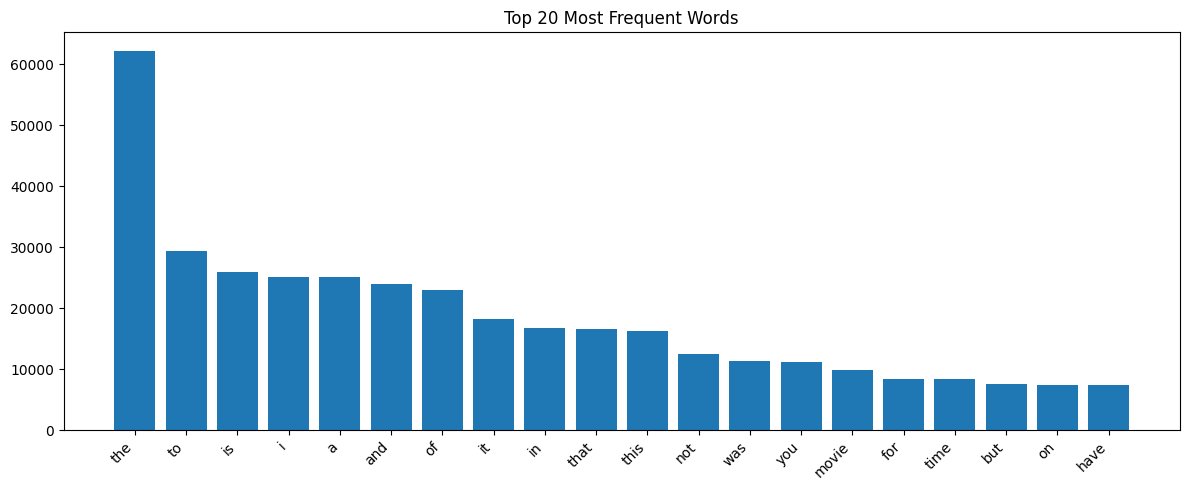

In [93]:
from collections import Counter
import matplotlib.pyplot as plt

# most repeated words
all_words = ' '.join(comments_df['translated_text']).lower().split()
word_freq = Counter(all_words).most_common(20)

words, counts = zip(*word_freq)
plt.figure(figsize=(12, 5))
plt.bar(words, counts)
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Frequent Words')
plt.tight_layout()
plt.show()

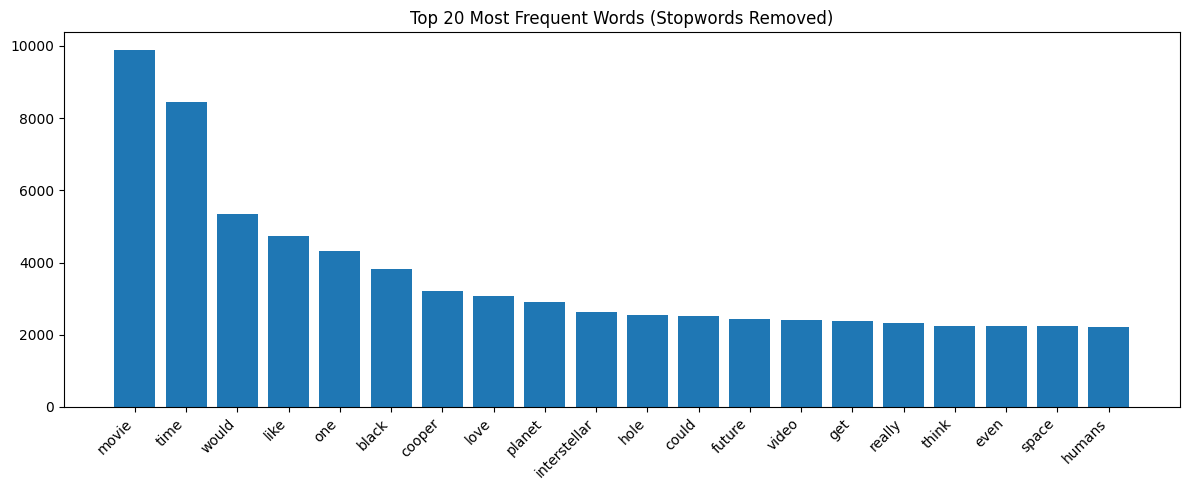

In [95]:
import nltk
from nltk.corpus import stopwords


stop_words = set(stopwords.words('english'))
filtered_words = [w for w in all_words if w not in stop_words and len(w) > 2]

word_freq = Counter(filtered_words).most_common(20)
words, counts = zip(*word_freq)

plt.figure(figsize=(12, 5))
plt.bar(words, counts)
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Frequent Words (Stopwords Removed)')
plt.tight_layout()
plt.show()